## Volume of Aluminum Probe

In [1]:
import numpy as np

diameter = 17.52 #mm
radius = diameter / 2 #mm
length = 52.2 #mm

cylinder_vol_mm3 = radius**2 * np.pi * length #mm^3
cylinder_vol_cm3 = cylinder_vol_mm3 / 1000 #cm^3

cone_height = 8.02 #mm
cone_volume_mm3 = (1/3) * np.pi * radius**2 * cone_height
cone_volume_cm3 = cone_volume_mm3 / 1000 #cm^3


four_fin_mass = 1.27 #g
PLA_density = 1.43 #g/cm
four_fin_vol_cm3 = four_fin_mass / PLA_density

probe_vol_cm3 = cylinder_vol_cm3 + cone_volume_cm3 + four_fin_vol_cm3
print(f"Probe volume: {probe_vol_cm3:.2f} cm^3")

Probe volume: 14.12 cm^3


## Weighing Probe
Note that the wires/tail of probe are mostly off the scale. This is intentional, with the goal of measureing the weight of the probe without wires.

<img src="doc_images\how_to_mass_probe.jpeg" alt="Description" width="35%" height="35%">

In [2]:
probe_mass = 40.
d = probe_mass / probe_vol_cm3
print(d)

2.8334871398801647


In [3]:
1.575-.736

0.839

Density of Wet Sand

In [4]:
rho_wet_sand = 1.964

## 16v might be the limit
Motor was ran for 20 second intervals, increasing voltage by 1.0v at a time
Motor started smoking ~10 seconds into 17 volt test

Trying to identify Mystery metal

In [5]:
import numpy as np
mass = 957 #g
diameter = 1.94 #cm
length = 20.64 #cm
density = mass / (np.pi * (diameter/2)**2 * length)
print(f"Density: {density:.2f} g/cm^3")

Density: 15.69 g/cm^3


In [6]:
import re
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import trim_data_file
probe_length = 60.2

source_csv = r"Data\frequencyVdepth5.csv"
trimmed_csv = Path(re.sub(r"(\.csv)$", r"_trimmed\1", source_csv))

trim_data_file.trim_csv_to_consistent_format(source_csv, trimmed_csv)
data = pd.read_csv(trimmed_csv)

# drop last 2 rows for now
#data = data.iloc[:-2]


## Adding some plot settings

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
from scipy.stats import chi2

mass_colors = {
    1: "green",
    3: [0, 110/255, 1],
    5: [1, 138/255, 0],
}

mass_order = [1, 3, 5]
#moment_of_inertia: 7.449661e-09 kg*m^2
# plate mass = 0.477g

plate_mass_kg = 0.477e-3          # 0.477 g
plate_moment_of_inertia_kg_m2 = 7.449661e-09
r_eff = np.sqrt(plate_moment_of_inertia_kg_m2 / plate_mass_kg)
#plot limits
pf = 251
pd = 1.31
pp = 1401

# starting depth ~11mm
sd = cone_height + 3.0

def _plot_confidence_ellipse(ax, x_vals, y_vals, color, confidence_level, alpha=0.3):
    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)

    if len(x_vals) < 2 or len(y_vals) < 2:
        return

    x_mean = x_vals.mean()
    y_mean = y_vals.mean()
    centered = np.column_stack([x_vals - x_mean, y_vals - y_mean])
    covariance = np.cov(centered, rowvar=False)

    if np.allclose(covariance, 0):
        return

    eigvals, eigvecs = np.linalg.eigh(covariance)
    eigvals = np.clip(eigvals, 1e-8, None)

    scale = np.sqrt(chi2.ppf(confidence_level, df=2))
    angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
    width = 2 * np.sqrt(eigvals[1]) * scale
    height = 2 * np.sqrt(eigvals[0]) * scale

    ellipse = Ellipse(
        (x_mean, y_mean),
        width=width,
        height=height,
        angle=angle,
        facecolor=color,
        edgecolor=color,
        alpha=alpha,
    )
    ax.add_patch(ellipse)
    ax.plot(x_mean, y_mean, "o", color=color, markersize=4)
    return x_mean, y_mean


def plot_mass_scatter(
    data,
    x_func,
    y_func,
    xlabel,
    ylabel,
    *,
    xlim=None,
    ylim=None,
    legend_loc="best",
    grid=True,
    confidence_ellipse=False,
    group_col="Voltage (V)",
    confidence_level=0.7,
    label_erm=True,
    **kwargs,
):
    fig, ax = plt.subplots()
    legend_handles = []
    legend_labels = []

    for mass in mass_order:
        subset = data[data["ERM Mass"] == mass]

        if confidence_ellipse and group_col in subset.columns:
            for _, group_subset in subset.groupby(group_col):
                x_vals = x_func(group_subset, mass)
                y_vals = y_func(group_subset, mass)
                _plot_confidence_ellipse(
                    ax,
                    x_vals,
                    y_vals,
                    mass_colors[mass],
                    confidence_level=confidence_level,
                )

            if label_erm:
                handle = plt.Line2D(
                    [0], [0],
                    marker="o",
                    linestyle="None",
                    color=mass_colors[mass],
                    markerfacecolor=mass_colors[mass],
                    markeredgecolor=mass_colors[mass],
                    markersize=8,
                )
                legend_handles.append(handle)
                legend_labels.append(f"ERM {mass}")
        else:
            x_vals = x_func(subset, mass)
            y_vals = y_func(subset, mass)
            ax.scatter(
                x_vals,
                y_vals,
                marker="o",
                color=mass_colors[mass],
                label=f"ERM Mass {mass}",
                **kwargs,
            )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    if legend_handles:
        ax.legend(legend_handles, legend_labels, loc=legend_loc)
    else:
        ax.legend(loc=legend_loc)

    if grid:
        ax.grid(True, alpha=0.3)
    return ax


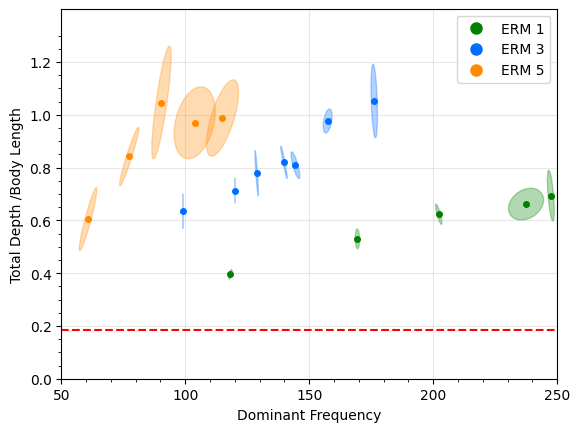

In [8]:
# Frq vs Depth
ax = plot_mass_scatter(
    data,
    lambda subset, mass: subset["Peak Frequency"].astype(float),
    lambda subset, mass: (subset["Total Depth (mm)"] / probe_length).astype(float),
    "Dominant Frequency",
    "Total Depth /Body Length",
    xlim=(50, 250),
    ylim=(0, 1.4),
    confidence_ellipse=1,
)
# offsets
a = 0
b = 0

ax.set_yticks(np.arange(0, pd+a, 0.2))
ax.set_yticks(np.arange(0, pd+a, 0.2/4), minor=True)
ax.set_xticks(np.arange(50, pf+b, 50))
ax.set_xticks(np.arange(50, pf+b, 10), minor=True)
# add line at y = 8/probe length
ax.axhline(y=sd/probe_length, color='red', linestyle='--', label='starting depth')
plt.show()


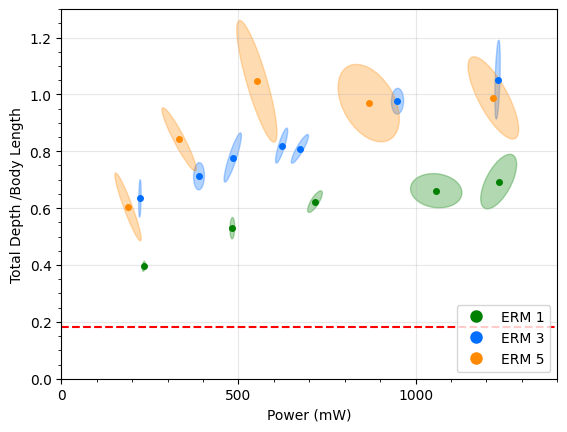

In [9]:
# Power vs Depth
ax = plot_mass_scatter(
    data,
    lambda subset, mass: subset["Power (mW)"].astype(float),
    lambda subset, mass: subset["Total Depth (mm)"].astype(float) / probe_length,
    "Power (mW)",
    "Total Depth /Body Length",
    xlim=(0, 1400),
    ylim=(0, 1.2),
    legend_loc="lower right",
    confidence_ellipse=1,
)
a = 0
b = 00

ax.set_yticks(np.arange(0, pd+a, 0.2))
ax.set_yticks(np.arange(0, pd+a, 0.2/4), minor=True)
ax.set_xticks(np.arange(0, pp+b, 500))
ax.set_xticks(np.arange(0, pp+b, 100), minor=True)
ax.axhline(y=sd/probe_length, color='red', linestyle='--', label='starting depth')

plt.show()


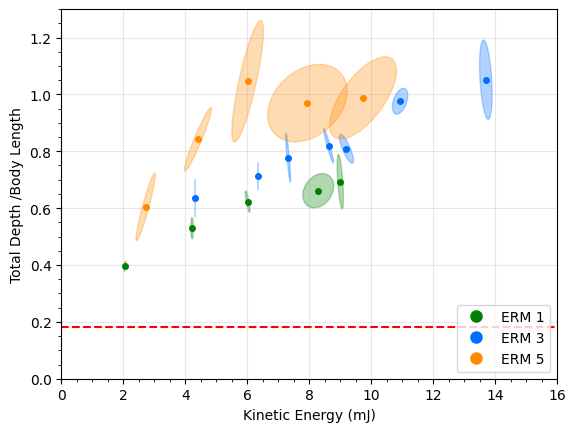

In [10]:
# Plot kinetic power vs depth
ax = plot_mass_scatter(
    data,
    lambda subset, mass: 0.5 * mass * plate_moment_of_inertia_kg_m2 * (2 * np.pi * subset["Peak Frequency"].astype(float))**2 * 1000,
    lambda subset, mass: subset["Total Depth (mm)"] / probe_length,
    "Kinetic Energy (mJ)",
    "Total Depth /Body Length",
    legend_loc="lower right",
    confidence_ellipse=True,
)

ax.set_yticks(np.arange(0, 1.31, 0.2))
ax.set_yticks(np.arange(0, 1.31, 0.2/4), minor=True)
ax.set_xticks(np.arange(0, 16.1, 2))
ax.set_xticks(np.arange(0, 16.1, .5), minor=True)
ax.axhline(y=sd/probe_length, color='red', linestyle='--', label='starting depth')

plt.show()


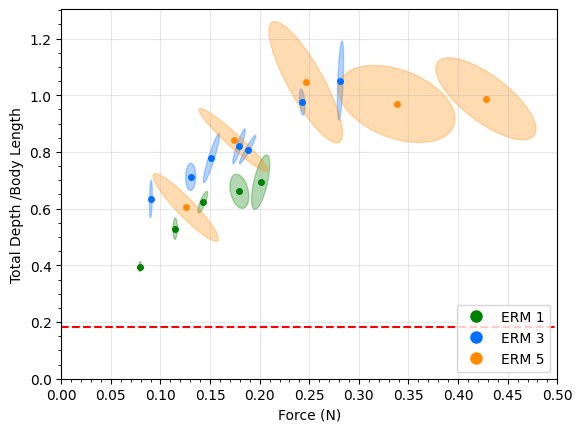

In [11]:
# Force = Power / Angular Velocity
r = 0.005  # distance from center of probe to center of ERM mass
ax = plot_mass_scatter(
    data,
    lambda subset, mass: subset["Power (mW)"].astype(float) * 0.001 / ((2 * np.pi * subset["Peak Frequency"].astype(float)) * r_eff),
    lambda subset, mass: subset["Total Depth (mm)"] / probe_length,
    "Force (N)",
    "Total Depth /Body Length",
    legend_loc="lower right",
    confidence_ellipse=1,
)

ax.set_yticks(np.arange(0, 1.31, 0.2))
ax.set_yticks(np.arange(0, 1.31, 0.2/4), minor=True)
ax.set_xticks(np.arange(0, 0.501, 0.05))
ax.set_xticks(np.arange(0, 0.501, 0.05/5), minor=True)
ax.axhline(y=sd/probe_length, color='red', linestyle='--', label='starting depth')

plt.show()


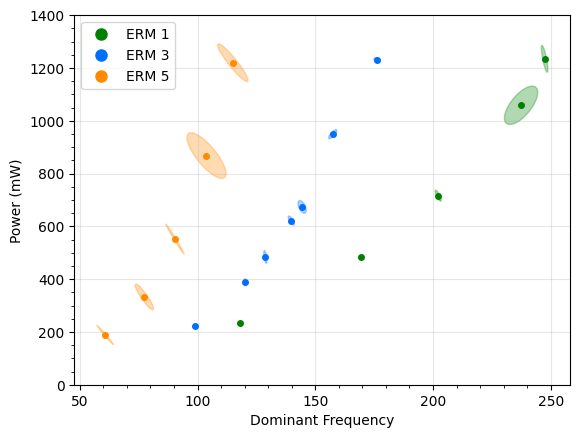

In [12]:
# Power Draw vs Frequency
ax = plot_mass_scatter(
    data,
    lambda subset, mass: subset["Peak Frequency"].astype(float),
    lambda subset, mass: subset["Power (mW)"].astype(float),
    "Dominant Frequency",
    "Power (mW)",
    legend_loc="best",
    confidence_ellipse=True,

)
ax.set_yticks(np.arange(0, 1401, 200))
ax.set_yticks(np.arange(0, 1401, 50), minor=True)
ax.set_xticks(np.arange(50, 251, 50))
ax.set_xticks(np.arange(50, 251, 10), minor=True)
plt.show()


## Frequncy Spectrum

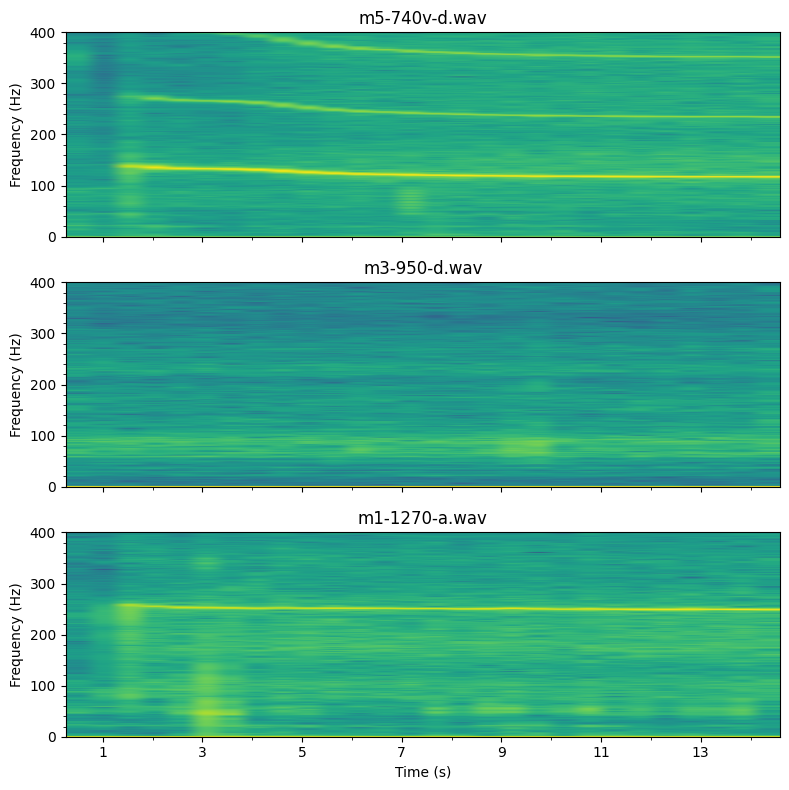

In [61]:
import os
from scipy.io import wavfile

wav_files = [
    ("m5-740v-d.wav", 40),
    ("m3-950-d.wav", 45),
    ("m1-1270-a.wav", 20),
]
duration_sec = 15

fig, axes = plt.subplots(len(wav_files), 1, figsize=(8, 8), sharex=True)

for ax, (wav_name, trial_start_sec) in zip(axes, wav_files):
    wav_path = os.path.join(os.getcwd(), "Data", wav_name)
    sample_rate, audio = wavfile.read(wav_path)

    start_sec = trial_start_sec
    end_sec = trial_start_sec + duration_sec
    start_sample = int(start_sec * sample_rate)
    end_sample = int(min(end_sec * sample_rate, len(audio)))
    audio_slice = audio[start_sample:end_sample]

    if audio_slice.ndim > 1:
        audio_slice = audio_slice.mean(axis=1)

    window = 4096
    noverlap = window // 2

    plt.sca(ax)
    Pxx, freqs, bins, im = plt.specgram(
        audio_slice,
        Fs=sample_rate,
        NFFT=window,
        noverlap=noverlap,
        cmap="viridis",
    )

    ax.set_title(wav_name)
    ax.set_ylabel("Frequency (Hz)")
    ax.set_ylim(0, 400)
    ax.set_yticks(np.arange(0, 401, 100))
    ax.set_yticks(np.arange(0, 401, 20), minor=True)


axes[-1].set_xlabel("Time (s)")
# axes[-1].set_xlim(0, duration_sec)
axes[-1].set_xticks(np.arange(1, duration_sec, 2))
axes[-1].set_xticks(np.arange(1, duration_sec, 1), minor=True)

fig.tight_layout()
plt.show()


## (Depth in Body Lengths/Power) vs Frequency
## (Depth in Body Lengths/Voltage) vs Frequency
## (Depth in Body Lengths/Force) vs Frequency

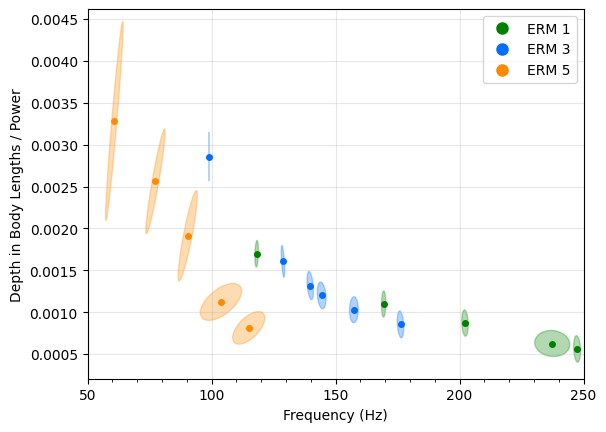

In [14]:
# (Depth in Body Lengths / Power) vs Frequency
ax = plot_mass_scatter(
    data,
    lambda subset, mass: subset["Peak Frequency"].astype(float),
    lambda subset, mass: (subset["Total Depth (mm)"].astype(float) / probe_length) / subset["Power (mW)"].astype(float),
    "Frequency (Hz)",
    "Depth in Body Lengths / Power",
    xlim=(50, 250),
    legend_loc="best",
    confidence_ellipse=True,
)
ax.set_xticks(np.arange(50, 251, 50))
ax.set_xticks(np.arange(50, 251, 10), minor=True)
plt.show()


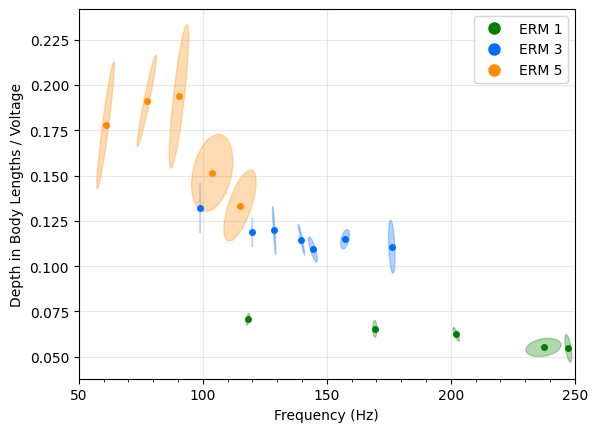

In [15]:
# (Depth in Body Lengths / Voltage) vs Frequency
ax = plot_mass_scatter(
    data,
    lambda subset, mass: subset["Peak Frequency"].astype(float),
    lambda subset, mass: (subset["Total Depth (mm)"].astype(float) / probe_length) / subset["Voltage (V)"].astype(float),
    "Frequency (Hz)",
    "Depth in Body Lengths / Voltage",
    xlim=(50, 250),
    legend_loc="best",
    confidence_ellipse=True,
)
ax.set_xticks(np.arange(50, 251, 50))
ax.set_xticks(np.arange(50, 251, 10), minor=True)
plt.show()


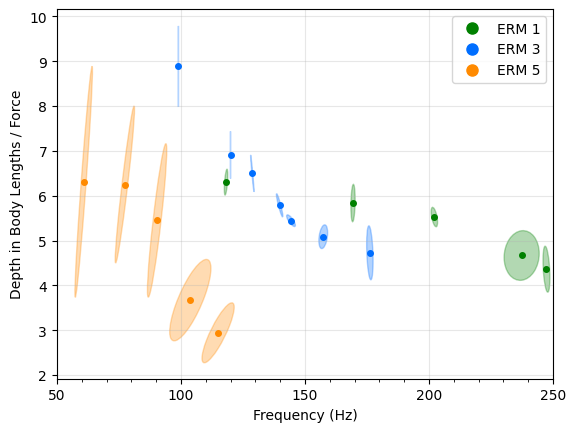

In [16]:
# (Depth in Body Lengths / Force) vs Frequency
ax = plot_mass_scatter(
    data,
    lambda subset, mass: subset["Peak Frequency"].astype(float),
    lambda subset, mass: (subset["Total Depth (mm)"].astype(float) / probe_length) / (
        subset["Power (mW)"].astype(float) * 0.001 / ((2 * np.pi * subset["Peak Frequency"].astype(float)) * 0.005)
    ),
    "Frequency (Hz)",
    "Depth in Body Lengths / Force",
    xlim=(50, 250),
    legend_loc="best",
    confidence_ellipse=True,
)
ax.set_xticks(np.arange(50, 251, 50))
ax.set_xticks(np.arange(50, 251, 10), minor=True)
plt.show()


# Comparing Duration vs Depth

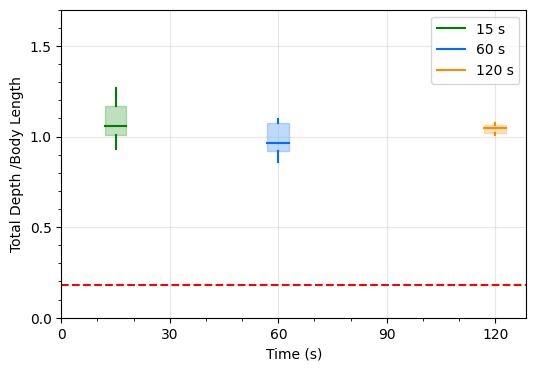

In [17]:
from matplotlib.patches import Rectangle
import pandas as pd

# Load the time-trial measurements and map each run to a pseudo-ERM group.
time_path = Path(r"Data\time-trials.csv")
time_trials = pd.read_csv(time_path)
time_trials["Time (s)"] = time_trials["Time (s)"].astype(int)

original_mass_order = mass_order
original_mass_colors = mass_colors.copy()

time_order = [15, 60, 120]
time_colors = {
    15: "green",
    60: [0, 110 / 255, 1],
    120: [1, 138 / 255, 0],
}

fig, ax = plt.subplots(figsize=(6, 4))
for time in time_order:
    subset = time_trials[time_trials["Time (s)"] == time]
    x_vals = subset["Time (s)"].astype(float)
    y_vals = subset["Total Depth (mm)"].astype(float)/probe_length

    x_center = x_vals.mean()
    q_low = np.percentile(y_vals, 15)
    q_high = np.percentile(y_vals, 85)
    whisk_low = y_vals.min()
    whisk_high = y_vals.max()
    median_y = np.median(y_vals)
    box_width = 6

    ax.add_patch(
        Rectangle(
            (x_center - box_width / 2, q_low),
            box_width,
            q_high - q_low,
            facecolor=time_colors[time],
            edgecolor=time_colors[time],
            alpha=0.25,
        )
    )
    ax.plot([x_center, x_center], [whisk_low, q_low], color=time_colors[time], linewidth=1.5)
    ax.plot([x_center, x_center], [q_high, whisk_high], color=time_colors[time], linewidth=1.5)
    ax.plot(
        [x_center - box_width / 2, x_center + box_width / 2],
        [median_y, median_y],
        color=time_colors[time],
        linewidth=1.5,
        label=f"{time} s"
    )

ax.set_xticks(np.arange(0, 121, 30))
ax.set_xticks(np.arange(0, 121, 10), minor=True)
ax.set_yticks(np.arange(0, 1.75, .5))
ax.set_yticks(np.arange(0, 1.75, .1), minor=True)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Total Depth /Body Length")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.axhline(y=sd/probe_length, color='red', linestyle='--', label='starting depth')

plt.show()


# Power over time

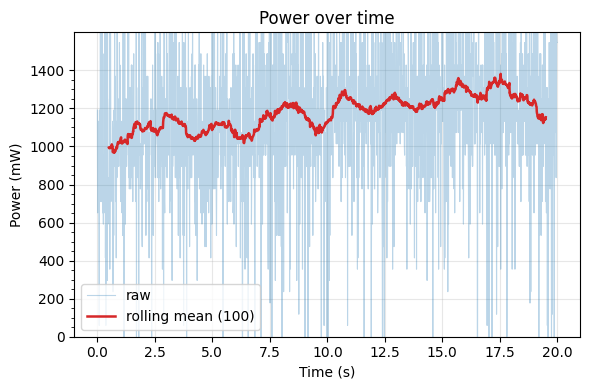

In [75]:
power_path = Path(r"Data\scope_1.csv")
power_data = pd.read_csv(power_path)
power_data["second"] = power_data["second"].astype(float) + 10
power_data["Voltage_sense"] = -1 * power_data["Volt"].astype(float)

test_voltage = 7.40  # Load voltage
sense_resistance = 0.1  # Ohms

power_data["Current"] = power_data["Voltage_sense"] / sense_resistance
power_data["Power (mW)"] = 1000 * test_voltage * power_data["Current"]

# Apply smoothing with a rolling mean.
window = 100
power_data["Power (mW) rolling"] = power_data["Power (mW)"].rolling(window, center=True, min_periods=window).mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(power_data["second"], power_data["Power (mW)"], color="tab:blue", linewidth=0.8, alpha=0.3, label="raw")
ax.plot(power_data["second"], power_data["Power (mW) rolling"], color="tab:red", linewidth=1.8, label=f"rolling mean ({window})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (mW)")
ax.set_title("Power over time")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
ax.set_yticks(np.arange(0, 1401, 200))
ax.set_yticks(np.arange(0, 1401, 50), minor=True)
ax.set_ylim(0, 1600)
plt.tight_layout()
plt.show()
